In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

countries = ["ethiopia", "kenya", "tanzania", "nigeria", "sudan"]

all_data = []

for country in countries:
    file_path = f"../data/{country}.csv"
    
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip().str.lower()

    df["date"] = pd.to_datetime(
        df["year"].astype(str) + df["doy"].astype(str),
        format="%Y%j",
        errors="coerce"
    )

    df["month"] = df["date"].dt.month

    df["country"] = country  # important for comparison

    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)

combined.head()

,year,doy,t2m,t2m_max,t2m_min,t2m_range,prectotcorr,rh2m,ws2m,ws2m_max,ps,qv2m,date,month,country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,ethiopia


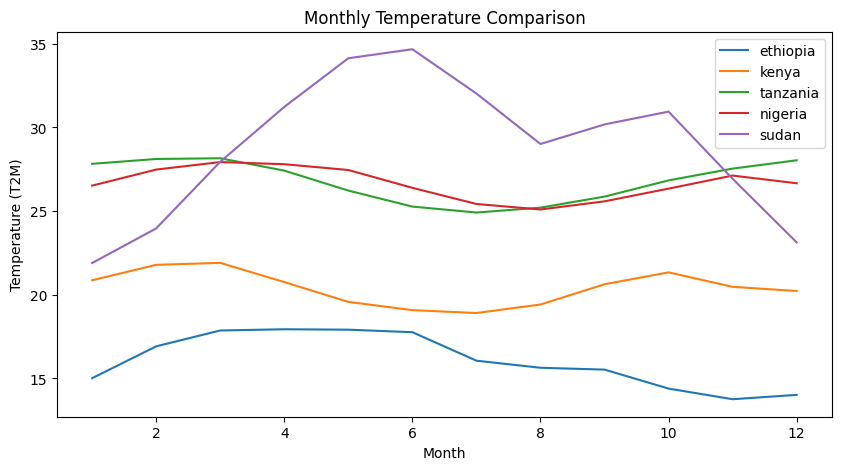

In [3]:
temp_compare = combined.groupby(["country", "month"])["t2m"].mean().reset_index()

plt.figure(figsize=(10,5))

for country in countries:
    data = temp_compare[temp_compare["country"] == country]
    plt.plot(data["month"], data["t2m"], label=country)

plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

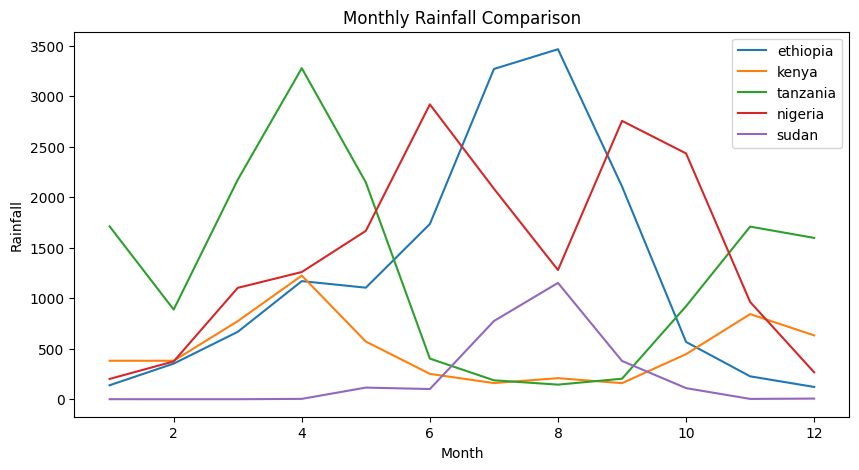

In [4]:
rain_compare = combined.groupby(["country", "month"])["prectotcorr"].sum().reset_index()

plt.figure(figsize=(10,5))

for country in countries:
    data = rain_compare[rain_compare["country"] == country]
    plt.plot(data["month"], data["prectotcorr"], label=country)

plt.title("Monthly Rainfall Comparison")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.legend()
plt.show()